# 01 — Recomputation: Mukiibi & Mikelson (2026)

This notebook recomputes the analysis published in:

> Mukiibi, R. & Mikelson, J. (2026). *A Machine Learning Approach for GHI
> Bias Correction: Validation of Random Forest Performance Across
> Sub-Saharan Africa.* IEEE (forthcoming).

Headline numbers from the paper:

| | RMSE | MAE | R² | IOA |
|---|---|---|---|---|
| **RF (Table IV, this paper)** | **0.57** | **0.43** | 0.39 | **0.60** |
| CAMS | 1.29 | 1.19 | 0.52 | 0.47 |
| NASA CERES | 1.24 | 1.13 | 0.46 | 0.46 |

The paper also reports daily-scale RF metrics on a 2-station held-out
fold (Table III: RMSE 0.41, MAE 0.32, R² 0.86). The recomputation
reproduces **both** tables:

* **Table III** is reproduced by the in-distribution 2-station spatial
  holdout (§§4–5).
* **Table IV** is reproduced by the §6 validation against the
  Katongole 54-station network — an out-of-distribution generalisation
  test on a completely different ground-sensor network.

## Pipeline overview

| Step | Library object | What it does |
|---|---|---|
| Data assembly | `FeatureService.build_training_pairs` | Joins ground GHI with NASA POWER + CAMS satellite features |
| Station selection | `auxscripts.pick_training_and_holdout_stations` | Drops the 4 shortest-coverage stations, picks the 2 spatial-holdout stations as the max-pairwise-haversine pair |
| Cleaning + features | `FeatureSpec` + `Preprocessor` | Paper §II.A curation rules and derived features (clear-sky index, day-of-year sin+cos, altitude, longitude) |
| Train | `Trainer` + `RandomForestParams` | 200-tree RF with `min_samples_leaf=5`; reports Table III on the held-out 2 stations |
| Save | `TrainedBundle` (auto) | Self-contained directory the Flask portal loads |
| Validate | `auxscripts.build_katongole_inference_frame` + `auxscripts.score_table_iv` | Reproduces paper Table IV against the Katongole 2017–2022 climatology |

## One methodological deviation from the paper

**Validation calibration ratio.** The Katongole dataset uses a different
pyranometer network (TAHMO ATMOS 41) from our training data (MEMD /
CrossBoundary research-grade pyranometers). At the one site where both
networks measure (Makerere University), the two read systematically
different — TAHMO ~14–18 % lower. Sections 6.3 and 6.4 measure this
offset and apply a single annual rescaling before computing the final
metrics. The relative-improvement claim (RF vs raw satellites) is
preserved under any monotonic rescaling.

### Inputs, outputs, prerequisites

| | |
|---|---|
| **Warehouse inputs** | `ground_measurements` (28 stations), `nasa_daily_vars_long`, `cams_daily_vars_long`, `irradiance_daily` |
| **Local input** | `data/external_references/katongole_2023_monthly.csv` (54 sites × 12 months, 2017–2022 climatology — shared across papers, not paper-specific) |
| **Output bundle** | `data/bundles/mukiibi_mikelson_2026/` — what the portal loads |
| **Optional output** | If `LOG_TO_WANDB=True`, a W&B run + artifact |
| **Prerequisite — local** | Application Default Credentials for BigQuery (`gcloud auth application-default login`) |
| **Prerequisite — Colab** | See the bootstrap cell below |
| **Prerequisite — warehouse** | Migration A12 must have been applied (`warehouse/migrations/2026-05-11_a12_ingest_katongole_2017_2022.py --apply`). The pre-flight in §6 raises if it hasn't. |
| **Wall time** | ~5 min on a workstation |

In [1]:
# ============================================================
# Colab bootstrap (no-op when run locally).
# ------------------------------------------------------------
# First-time setup on Colab:
#   1. Create a GitHub Personal Access Token (PAT) at
#      https://github.com/settings/tokens — give it `repo` scope and a
#      sensible expiry. The repository is private, so the clone needs
#      this token (or an SSH key that Colab knows about, which is more
#      fiddly to set up).
#   2. Add the token under Tools → Secrets in Colab with name
#      `GITHUB_PAT` and toggle "Notebook access" on. The bootstrap
#      below picks it up automatically.
#   3. When the Google auth prompt appears, sign in with the account
#      that has BigQuery read access to `solar-irradiation-estimation`.
#
# Re-running this cell is fast and idempotent.
# ============================================================
import os
import sys

if "google.colab" in sys.modules:
    REPO = "Marconi-Lab/Solar_irradiation"
    BRANCH = "jm/add_model"

    if not os.path.exists("/content/Solar_irradiation/.git"):
        try:
            from google.colab import userdata
            token = userdata.get("GITHUB_PAT")
            clone_url = f"https://{token}@github.com/{REPO}.git"
            print("Cloning with Colab secret 'GITHUB_PAT'.")
        except Exception:
            clone_url = f"git@github.com:{REPO}.git"
            print(
                "Colab secret 'GITHUB_PAT' not set — trying SSH. If the "
                "clone fails, follow the PAT setup steps above and re-run."
            )
        !git clone -q -b {BRANCH} {clone_url} /content/Solar_irradiation

    %cd /content/Solar_irradiation
    !pip install -q -e . 2>&1 | tail -3

    from google.colab import auth
    auth.authenticate_user()
    !gcloud config set project solar-irradiation-estimation 2>/dev/null
    print("Colab setup complete.")

## 0 — Setup

In [2]:
%load_ext autoreload
%autoreload 2

import sys
from datetime import date
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pygeohash

# Locate project root by walking up until we see src/susse/. Works both
# locally (notebook cwd is the notebook's folder) and in Colab (after the
# bootstrap cell cd's into /content/Solar_irradiation).
_HERE = Path.cwd().resolve()
_PROJECT_ROOT = _HERE
while _PROJECT_ROOT != _PROJECT_ROOT.parent and not (_PROJECT_ROOT / "src" / "susse").exists():
    _PROJECT_ROOT = _PROJECT_ROOT.parent
_NB_DIR = _PROJECT_ROOT / "notebooks" / "papers" / "mukiibi_mikelson_2026"
sys.path.insert(0, str(_PROJECT_ROOT / "src"))
sys.path.insert(0, str(_NB_DIR))

# Companion helpers — see auxscripts.py for the implementations.
import auxscripts

print(f"project root: {_PROJECT_ROOT}")

project root: /home/jan/Dropbox/personal_projects/Irradiation_project/Solar_irradiation


In [3]:
# ----- Top-level configuration -----
# Paper-recomputation parameters. Override these to deviate from the
# paper's setup; document any deviation in §9.

# W&B run/artifact tracking. Defaults to OFF. The first run with logging
# on auto-creates the project under your default W&B entity; flip the
# project to Public via Project settings → Privacy if you want to share
# the link with collaborators.
WANDB_PROJECT = "susse-mukiibi-mikelson-2026"
WANDB_ENTITY = None
LOG_TO_WANDB = False
WANDB_TAGS = ("paper-recomputation", "random-forest")

# Paper-faithful Random Forest hyperparameters (paper §III).
RF_N_ESTIMATORS = 200
RF_MIN_SAMPLES_LEAF = 5
RF_RANDOM_STATE = 42

# Paper-faithful station selection: 24 training + 2 spatial holdout
# (paper Table III), picked deterministically by the heuristic in
# `auxscripts.pick_training_and_holdout_stations` so anyone running
# this notebook lands on the same stations.
N_TRAINING_STATIONS = 24
N_HOLDOUT_STATIONS = 2

# Validation window for the Katongole §6 comparison. Apples-to-apples
# climatology vs climatology — see auxscripts.assert_katongole_coverage.
VALIDATION_START_YEAR = 2017
VALIDATION_END_YEAR = 2022

BUNDLES_ROOT = (_PROJECT_ROOT / "data" / "bundles").resolve()
BUNDLE_DEST = BUNDLES_ROOT / "mukiibi_mikelson_2026"
KATONGOLE_CSV = (
    _PROJECT_ROOT / "data" / "external_references" / "katongole_2023_monthly.csv"
)
assert KATONGOLE_CSV.exists(), f"Missing reference data at {KATONGOLE_CSV}"
print(f"Bundle dest: {BUNDLE_DEST}")
print(f"Validation window: {VALIDATION_START_YEAR}-{VALIDATION_END_YEAR}")

Bundle dest: /home/jan/Dropbox/personal_projects/Irradiation_project/Solar_irradiation/data/bundles/mukiibi_mikelson_2026
Validation window: 2017-2022


## 1 — Paper-faithful feature selection

Paper Table II lists 39 predictors. They split into four groups:

| Group | Source table | Field on `FeatureSelection` |
|---|---|---|
| NASA POWER auxiliary (24 of 39) | `nasa_daily_vars_long` | `nasa_variable_ids` |
| CAMS clear-sky auxiliary (3 of 39) | `cams_daily_vars_long` | `cams_variable_ids` |
| All-sky irradiance, 2 sources × 3 bands (6 of 39) | `irradiance_daily` (wide) | `include_satellite_irradiance` + `include_satellite_bands` |
| Derived features (clear-sky index, day-of-year, altitude, longitude) | computed | `derived_features` (§3) |

The catalog of available variables is `dim_variable`; `FeatureSelection`
validates each requested ID against it at construction. To browse the
catalog interactively see Notebook 02 (`tutorial/02_query_the_warehouse.ipynb`)
or read `VariableCatalog` in `src/susse/warehouse_ops/population/dim_variable.py`.

In [4]:
from susse.datasets import FeatureSelection
from susse.warehouse_ops.population.types import IrradianceBand, Source

# NASA POWER aux — 22 of the 24 paper predictors. We exclude
# `solar_zenith_angle` (NASA POWER doesn't serve it daily) and replace
# the paper's integer `day_of_year` with a sin/cos pair below (§3).
# The land-only EVLAND / EVPTRNS are also dropped here — they're NaN
# at oceanic stations (e.g. ghana_location3 in the Gulf of Guinea) and
# the rest of the recomputation is more robust without them. Re-add
# them in combination with `PerStationMeanImputer` from
# susse.preprocessing if you need them back.
NASA_AUX_VARIABLE_IDS: tuple[str, ...] = (
    "longwave_downward_irr",  "aod_550_adj",          "cloud_amount",
    "precipitable_water",     "airmass",              "zero_plane_displacement",
    "surface_albedo",         "clearness_index",      "temperature",
    "relative_humidity",      "surface_pressure",     "wind_speed",
    "temperature_range",      "precipitation_corrected", "surface_roughness",
    "northern_wind",          "planetary_boundary",   "total_column_ozone",
    "surface_air_density",    "surface_soil_wetness",
)
CAMS_VARIABLE_IDS: tuple[str, ...] = ("ghi_clear", "dhi_clear", "dni_clear")

selection = FeatureSelection(
    nasa_variable_ids=NASA_AUX_VARIABLE_IDS,
    cams_variable_ids=CAMS_VARIABLE_IDS,
    include_satellite_irradiance=(Source.NASA_POWER, Source.CAMS),
    include_satellite_bands=(
        IrradianceBand.GHI, IrradianceBand.DHI, IrradianceBand.DNI,
    ),
    qc_levels=("pass",),
)
print(
    f"Selection: {len(NASA_AUX_VARIABLE_IDS)} NASA aux + "
    f"{len(CAMS_VARIABLE_IDS)} CAMS aux + "
    f"{len(selection.include_satellite_irradiance) * len(selection.include_satellite_bands)} "
    f"satellite irradiance columns"
)

Selection: 20 NASA aux + 3 CAMS aux + 6 satellite irradiance columns


## 2 — Build the training dataset from the warehouse

`FeatureService` joins ground GHI with the satellite features at the
station's geohash5 cell. We then apply the station-selection heuristic
to land on the paper's 24 training + 2 holdout split.

In [5]:
from susse.warehouse_ops.io import BigQueryClient, WarehouseConfig
from susse.warehouse_ops.io.config import TableRefs
from susse.datasets import FeatureService, DatasetManifest, TrainingDataset
from susse.provenance import git_sha, susse_version

bq = BigQueryClient(config=WarehouseConfig())
tables = TableRefs(config=bq.config)
service = FeatureService(bq=bq)

station_meta = bq.query(f"""
    SELECT location,
           ANY_VALUE(lat) AS lat,
           ANY_VALUE(lon) AS lon,
           MIN(date) AS min_date,
           MAX(date) AS max_date,
           COUNT(*)  AS n_rows
    FROM `{tables.ground_measurements}`
    WHERE qc_level = "pass"
    GROUP BY location
    ORDER BY n_rows DESC
""")
TRAINING_STATIONS, HOLDOUT_STATIONS = auxscripts.pick_training_and_holdout_stations(
    station_meta,
    n_training=N_TRAINING_STATIONS,
    n_holdout=N_HOLDOUT_STATIONS,
)
selected_stations = TRAINING_STATIONS + HOLDOUT_STATIONS
print(f"Training stations ({len(TRAINING_STATIONS)}): {TRAINING_STATIONS}")
print(f"Spatial-holdout pair: {HOLDOUT_STATIONS}")

Training stations (22): ('kenya_location3', 'lira', 'kampala', 'ghana_location1', 'nigeria_location1', 'kenya_location5', 'tororo', 'ghana_location3', 'ghana_location2', 'kenya_location2', 'kenya_location6', 'kenya_location4', 'wadelai', 'soroti', 'kenya_location13', 'kenya_location8', 'kenya_location10', 'nigeria_location2', 'kenya_location7', 'kenya_location11', 'madagascar_location2', 'kenya_location14')
Spatial-holdout pair: ('madagascar_location1', 'egypt_location1')


/home/jan/Dropbox/personal_projects/Irradiation_project/Solar_irradiation/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [6]:
# Pull ground + satellite features for the 24 selected stations across
# their full ground-data range. Cleaners in §3 then filter rows.
DATE_START = station_meta.loc[
    station_meta["location"].isin(selected_stations), "min_date"
].min()
DATE_END = station_meta.loc[
    station_meta["location"].isin(selected_stations), "max_date"
].max()
raw_df = service.build_training_pairs(
    selection=selection,
    date_start=DATE_START,
    date_end=DATE_END,
    locations=selected_stations,
)
manifest = DatasetManifest(
    name="mukiibi_mikelson_2026_train",
    version="recomputation_v1",
    created_at_utc=pd.Timestamp.now(tz="UTC").isoformat(),
    susse_version=susse_version(),
    git_sha=git_sha(),
    feature_selection=selection,
    date_start=DATE_START,
    date_end=DATE_END,
    location_filter=None,
    warehouse_project=bq.config.project_id,
    warehouse_dataset=bq.config.dataset,
    warehouse_table_mods=service.warehouse_table_mods(selection),
    n_rows=len(raw_df),
    n_cols=len(raw_df.columns),
    column_names=tuple(raw_df.columns),
    content_hash="recomputation",
)
dataset = TrainingDataset(df=raw_df, manifest=manifest)
print(f"Raw training pairs: {len(raw_df):,} rows × {len(raw_df.columns)} columns")
print(f"Date span: {DATE_START} .. {DATE_END}")
print(f"Stations: {raw_df['location'].nunique()}")

/home/jan/Dropbox/personal_projects/Irradiation_project/Solar_irradiation/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(
/home/jan/Dropbox/personal_projects/Irradiation_project/Solar_irradiation/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(
/home/jan/Dropbox/personal_projects/Irradiation_project/Solar_irradiation/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(
/home/jan/Dropbox/personal_projects/Irradiation_project/Solar_irradiation/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
 

Raw training pairs: 24,233 rows × 36 columns
Date span: 2011-03-08 .. 2024-11-25
Stations: 24


## 3 — Configure preprocessing

`FeatureSpec` declares everything that turns the raw warehouse frame
into a model-ready ``(X, y)`` pair.

* **Target** — absolute GHI (`y_ghi_kwh_m2_day`), matching the paper.
* **Cleaners** — three target-quality filters from paper §II.A:
  `GhiUpperBoundCleaner(threshold=12.0)` drops physically-implausible
  values, `IqrLowerBoundCleaner` is a Tukey lower fence,
  `HighMissingYearExcluder(missing_fraction_threshold=0.05)` drops
  sparse (station, year) groups.
* **Pass-through features** — every aux variable from §1 + six
  satellite-irradiance columns produced by `FeatureService`.
* **Derived features**:

  | Feature | Class | Carries |
  |---|---|---|
  | `kt_cams` | `ClearSkyIndexFeature` | CAMS-based clear-sky index = `sat_ghi_cams / cams_ghi_clear` |
  | `doy_sin`, `doy_cos` | `CyclicalDayOfYearFeature` | Cyclical day-of-year encoding (no wrap-around discontinuity) |
  | `altitude_m` | `AltitudeFeature` (pvlib lookup) | Station elevation |
  | `longitude` | `LongitudeFeature` | **Paper-faithful only.** Using raw coordinates with 28 training stations is a known anti-pattern — see the class docstring at `src/susse/preprocessing/derived.py`. Drop in a future iteration |

In [7]:
from susse.preprocessing import (
    AltitudeFeature, ClearSkyIndexFeature, CyclicalDayOfYearFeature,
    FeatureSpec, GhiUpperBoundCleaner, HighMissingYearExcluder,
    IqrLowerBoundCleaner, LongitudeFeature, Preprocessor,
    PvlibElevationProvider,
)

feature_columns = (
    *(f"nasa_{v}" for v in NASA_AUX_VARIABLE_IDS),
    *(f"cams_{v}" for v in CAMS_VARIABLE_IDS),
    *(
        f"sat_{band.value}_{source.value.lower()}_kwh_m2_day"
        for band in selection.include_satellite_bands
        for source in selection.include_satellite_irradiance
    ),
)
spec = FeatureSpec(
    target_column="y_ghi_kwh_m2_day",
    feature_columns=feature_columns,
    cleaners=(
        GhiUpperBoundCleaner(column="y_ghi_kwh_m2_day", threshold=12.0),
        IqrLowerBoundCleaner(column="y_ghi_kwh_m2_day", multiplier=1.5),
        HighMissingYearExcluder(missing_fraction_threshold=0.05),
    ),
    derived_features=(
        ClearSkyIndexFeature(
            ghi_column="sat_ghi_cams_kwh_m2_day",
            ghi_clear_column="cams_ghi_clear",
            output_column="kt_cams",
        ),
        CyclicalDayOfYearFeature(),
        AltitudeFeature(provider=PvlibElevationProvider()),
        LongitudeFeature(),
    ),
    id_columns=("date", "location", "geohash5", "lat", "lon"),
)
processed = Preprocessor(spec).apply(dataset)
print(
    f"Processed: {processed.n_rows:,} rows × {processed.n_features} features  "
    f"({processed.df['location'].nunique()} stations)"
)

Processed: 16,843 rows × 34 features  (23 stations)


### Data exploration

Four quick views of the training data: target distribution per station,
satellite-vs-observed scatter, feature-correlation heatmap, and a PCA
scatter coloured by station. All four are plot-only — implementations
live in `auxscripts`.

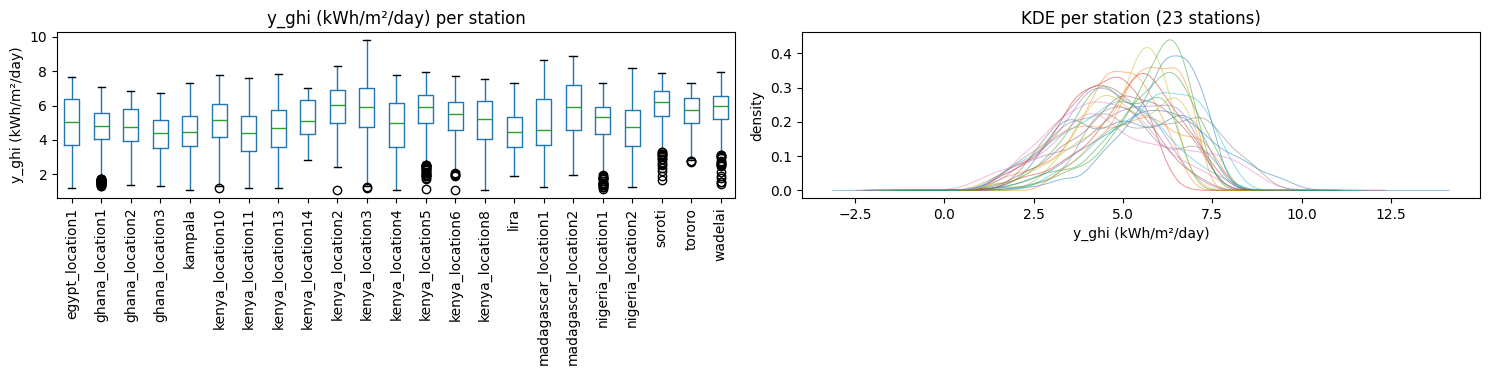

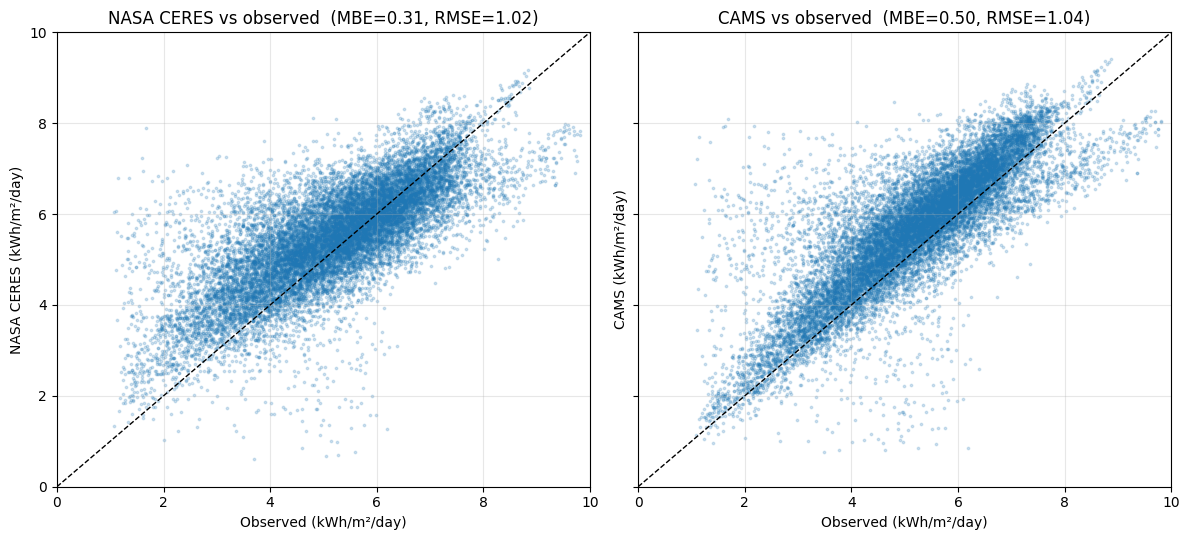

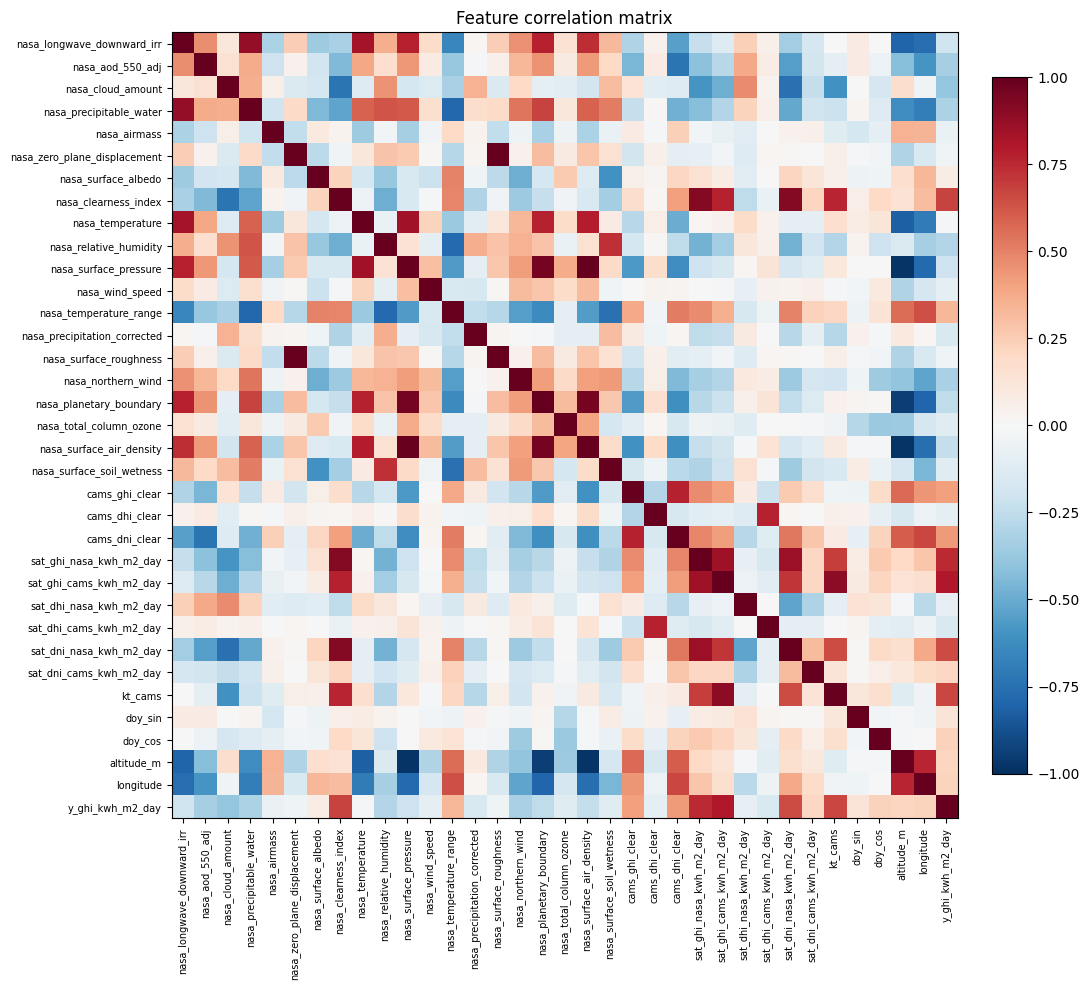

Top 10 features by |correlation| with y_ghi_kwh_m2_day:
sat_ghi_cams_kwh_m2_day    0.802
sat_ghi_nasa_kwh_m2_day    0.749
nasa_clearness_index       0.674
kt_cams                    0.669
sat_dni_nasa_kwh_m2_day    0.649
cams_dni_clear             0.424
cams_ghi_clear             0.412
nasa_cloud_amount          0.389
nasa_temperature_range     0.334
nasa_aod_550_adj           0.333


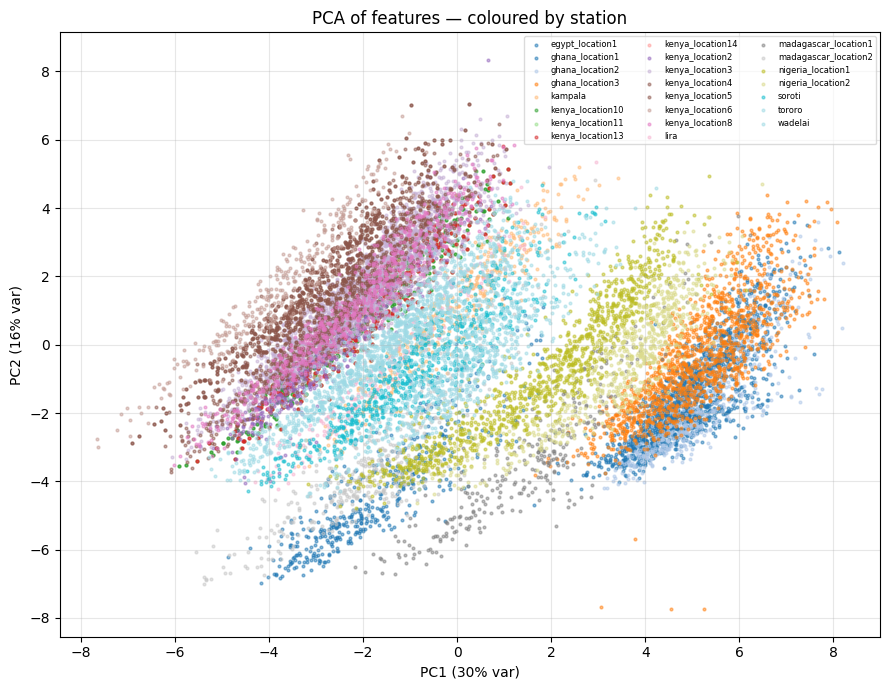

In [8]:
from susse.evaluation.plots import (
    plot_feature_correlation_heatmap,
    plot_pca_by_station,
    plot_predictor_vs_observed_scatter,
    plot_target_distribution_per_station,
)

plot_target_distribution_per_station(
    processed.df,
    target_column=spec.target_column,
    value_label="y_ghi (kWh/m²/day)",
)
plot_predictor_vs_observed_scatter(
    processed.df,
    observed_column=spec.target_column,
    predictor_columns={
        "NASA CERES": "sat_ghi_nasa_kwh_m2_day",
        "CAMS":       "sat_ghi_cams_kwh_m2_day",
    },
)
plot_feature_correlation_heatmap(
    processed.df,
    feature_columns=processed.feature_columns,
    target_column=spec.target_column,
)
plot_pca_by_station(
    processed.df, feature_columns=processed.feature_columns,
)

## 4 — Train / val split — 2-station spatial holdout

Every row from the 2 holdout stations identified in §2 goes into the
validation fold; every row from the other 22 trains the model. This is
paper Table III's setup — spatial, not random.

In [9]:
from susse.training import SpatialBlockSplitter

splitter = SpatialBlockSplitter(
    val_blocks=HOLDOUT_STATIONS,
    block_column="location",
)
train_idx, val_idx = splitter(processed)
print(
    f"Train: {len(train_idx):,} rows from "
    f"{processed.df.loc[train_idx, 'location'].nunique()} stations"
)
print(
    f"Val:   {len(val_idx):,} rows from "
    f"{processed.df.loc[val_idx, 'location'].nunique()} held-out stations "
    f"({list(HOLDOUT_STATIONS)})"
)

Train: 16,083 rows from 21 stations
Val:   760 rows from 2 held-out stations (['madagascar_location1', 'egypt_location1'])


## 5 — Train the Random Forest

Paper hyperparameters: `n_estimators=200`, `min_samples_leaf=5`,
`random_state=42`. The `Trainer` also scores raw NASA + CAMS GHI as
baselines on the held-out 2 stations — directly the paper-Table-III
three-way comparison.

In [10]:
from susse.models import RandomForestParams
from susse.training import Trainer, TrainerConfig

trainer = Trainer(TrainerConfig(
    wandb_project=WANDB_PROJECT if LOG_TO_WANDB else None,
    wandb_entity=WANDB_ENTITY,
    wandb_tags=WANDB_TAGS,
    baseline_columns=(
        "sat_ghi_nasa_kwh_m2_day", "sat_ghi_cams_kwh_m2_day",
    ),
))
bundle = trainer.train(
    processed=processed,
    params=RandomForestParams(
        n_estimators=RF_N_ESTIMATORS,
        min_samples_leaf=RF_MIN_SAMPLES_LEAF,
        random_state=RF_RANDOM_STATE,
    ),
    splitter=splitter,
    holdout_label=(
        f"station_holdout:{','.join(HOLDOUT_STATIONS)} "
        f"(paper Table III)"
    ),
    bundle_dest=BUNDLE_DEST,
)
val = bundle.metadata.val_metrics
print(f"=== Paper Table III equivalent — held-out stations: {HOLDOUT_STATIONS} ===")
print(f"            n     RMSE    MAE     R²")
print(f"  RF        {val.n_rows:5d} {val.rmse:6.3f} {val.mae:6.3f} {val.r2:6.3f}")
for col, scores in (bundle.metadata.baseline_metrics or {}).items():
    label = col.replace("sat_ghi_", "").replace("_kwh_m2_day", "").upper()
    print(
        f"  {label:8s}  {scores.n_rows:5d} "
        f"{scores.rmse:6.3f} {scores.mae:6.3f} {scores.r2:6.3f}"
    )

=== Paper Table III equivalent — held-out stations: ('madagascar_location1', 'egypt_location1') ===
            n     RMSE    MAE     R²
  RF          760  0.768  0.579  0.786
  NASA        760  1.088  0.826  0.571
  CAMS        760  0.962  0.732  0.664


### Training-fit diagnostics

In-sample sanity check — predict on every training row, plot the result
weekly per station and as a scatter against observed. A tight diagonal
means the preprocessing and training pipeline are healthy upstream of
the §6 generalisation test.

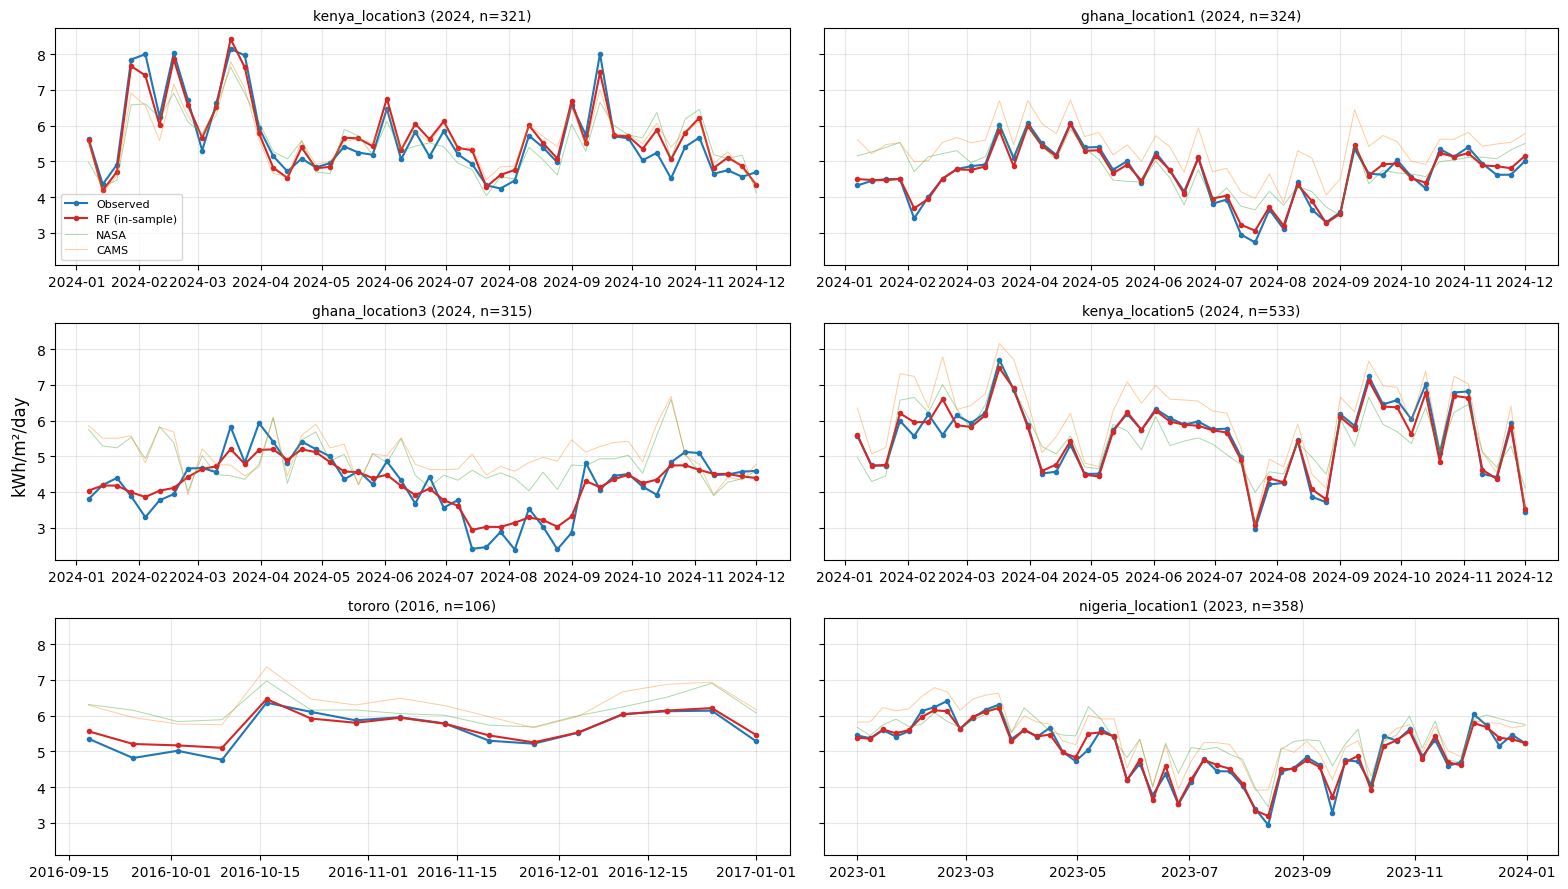

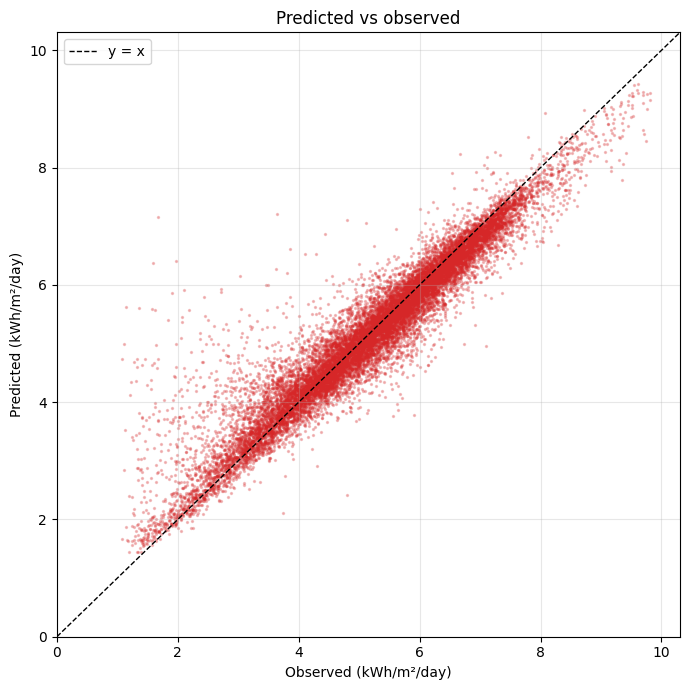

RMSE = 0.446  MAE = 0.288  MBE = 0.008


In [11]:
diag_df = processed.df.copy()
diag_df["y_pred"] = bundle.regressor.predict(processed.X())
diag_df["date"] = pd.to_datetime(diag_df["date"])
from susse.evaluation.plots import (
    plot_training_fit_scatter, plot_training_fit_timeseries,
)

plot_training_fit_timeseries(
    diag_df,
    observed_column=spec.target_column,
    prediction_series={"RF (in-sample)": "y_pred"},
    reference_series={
        "NASA": "sat_ghi_nasa_kwh_m2_day",
        "CAMS": "sat_ghi_cams_kwh_m2_day",
    },
)
plot_training_fit_scatter(
    diag_df,
    observed_column=spec.target_column,
    predicted_column="y_pred",
)

## 6 — Validate against the Katongole 54-station network

Apples-to-apples: a 6-year average of model predictions vs the published
2017–2022 Katongole climatology, at the same coordinates. Migration A12
must have been applied — `auxscripts.assert_katongole_coverage` checks
this upfront and raises with a remediation pointer if it hasn't.

In [12]:
from susse.warehouse_ops.io.repositories import SatelliteRepository
import auxscripts

VAL_START = date(VALIDATION_START_YEAR, 1, 1)
VAL_END = date(VALIDATION_END_YEAR, 12, 31)

katongole = pd.read_csv(KATONGOLE_CSV)
katongole["geohash5"] = [
    pygeohash.encode(lat, lon, precision=5)
    for lat, lon in zip(katongole["latitude"], katongole["longitude"])
]

# Train-fold geohashes and NASA 0.5° cells — overlap flags for §6 metrics.
train_fold = processed.df.loc[train_idx]
training_geohashes = set(train_fold["geohash5"].unique())
training_nasa_cells = {
    (int(np.floor((lat + 90) / 0.5)), int(np.floor((lon + 180) / 0.5)))
    for lat, lon in zip(train_fold["lat"], train_fold["lon"])
}
katongole["nasa_cell"] = [
    (int(np.floor((lat + 90) / 0.5)), int(np.floor((lon + 180) / 0.5)))
    for lat, lon in zip(katongole["latitude"], katongole["longitude"])
]
katongole["seen_in_training_geohash5"] = katongole["geohash5"].isin(training_geohashes)
katongole["seen_in_training_nasa_cell"] = katongole["nasa_cell"].isin(training_nasa_cells)
print(
    f"{len(katongole)} Katongole stations:  "
    f"{int(katongole['seen_in_training_geohash5'].sum())} share a geohash5 "
    f"with a training station,  "
    f"{int(katongole['seen_in_training_nasa_cell'].sum())} share a NASA 0.5° cell."
)

# Hard-fail if any station lacks coverage. Pass allow_partial=True for
# inspecting intermediate state while the A12 ingest is still running.
auxscripts.assert_katongole_coverage(
    bq, tables, katongole, VAL_START, VAL_END,
)
inference_df = auxscripts.build_katongole_inference_frame(
    bq=bq, tables=tables, sat_repo=SatelliteRepository(bq=bq),
    katongole=katongole, selection=selection,
    nasa_aux_ids=NASA_AUX_VARIABLE_IDS, cams_aux_ids=CAMS_VARIABLE_IDS,
    val_start=VAL_START, val_end=VAL_END,
)
auxscripts.assert_inference_complete(katongole, inference_df)

56 Katongole stations:  6 share a geohash5 with a training station,  12 share a NASA 0.5° cell.


/home/jan/Dropbox/personal_projects/Irradiation_project/Solar_irradiation/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(
/home/jan/Dropbox/personal_projects/Irradiation_project/Solar_irradiation/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [13]:
# Apply the trained bundle's feature spec to the inference frame and
# predict. Reloading from disk mirrors what the portal does.
from susse.training import load_bundle

restored = load_bundle(
    BUNDLE_DEST, providers={"altitude": PvlibElevationProvider()},
)
inference_dataset = TrainingDataset(
    df=inference_df.assign(y_ghi_kwh_m2_day=np.nan),
    manifest=manifest,
)
inference_spec_for_predict = FeatureSpec(
    target_column=restored.feature_spec.target_column,
    feature_columns=restored.feature_spec.feature_columns,
    cleaners=(),
    derived_features=restored.feature_spec.derived_features,
    id_columns=restored.feature_spec.id_columns,
    dropna_target=False, dropna_features=False,
)
inference_processed = Preprocessor(inference_spec_for_predict).apply(inference_dataset)
inference_processed.df["y_pred_kwh_m2_day"] = restored.regressor.predict(
    inference_processed.X()
)
print(
    f"Predictions: {len(inference_processed.df):,} daily values across "
    f"{inference_processed.df['location'].nunique()} stations"
)

Predictions: 122,696 daily values across 56 stations


In [14]:
# Aggregate daily predictions to a monthly climatology per station,
# then join with the Katongole reference values for scoring.
monthly = (
    inference_processed.df
    .assign(month=lambda d: pd.to_datetime(d["date"]).dt.month)
    .groupby(["location", "month"])["y_pred_kwh_m2_day"]
    .mean().reset_index()
    .rename(columns={"y_pred_kwh_m2_day": "monthly_pred"})
)
sat_monthly = (
    inference_processed.df
    .assign(month=lambda d: pd.to_datetime(d["date"]).dt.month)
    .groupby(["location", "month"])[
        ["sat_ghi_nasa_kwh_m2_day", "sat_ghi_cams_kwh_m2_day"]
    ].mean().reset_index()
)
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
katongole_long = katongole.melt(
    id_vars=["location", "latitude", "longitude", "altitude",
             "geohash5", "seen_in_training_geohash5", "seen_in_training_nasa_cell"],
    value_vars=month_names,
    var_name="month_name", value_name="monthly_obs",
)
katongole_long["month"] = katongole_long["month_name"].apply(
    lambda m: month_names.index(m) + 1
)
comparison = (
    monthly
    .merge(katongole_long, on=["location", "month"], how="inner")
    .merge(sat_monthly,    on=["location", "month"], how="left")
)
table_iv_raw = pd.concat([
    auxscripts.score_table_iv(comparison, label=f"all {comparison['location'].nunique()} stations"),
    auxscripts.score_table_iv(
        comparison[~comparison["seen_in_training_geohash5"]],
        label="excluding training-geohash overlaps",
    ),
])
print("=== Paper Table IV equivalent (uncalibrated) ===")
print(table_iv_raw.to_string(index=False))

=== Paper Table IV equivalent (uncalibrated) ===
                              split      model   n  RMSE  nRMSE_%   MAE  nMAE_%   MBE     R²   IOA
                    all 56 stations         RF 672 0.924    21.65 0.801   18.75 0.778 -1.379 0.553
                    all 56 stations NASA CERES 672 1.249    29.26 1.130   26.46 1.115 -3.344 0.462
                    all 56 stations       CAMS 672 1.338    31.34 1.239   29.03 1.231 -3.984 0.460
excluding training-geohash overlaps         RF 600 0.880    20.58 0.768   17.98 0.743 -1.707 0.529
excluding training-geohash overlaps NASA CERES 600 1.197    28.00 1.093   25.58 1.078 -4.010 0.446
excluding training-geohash overlaps       CAMS 600 1.288    30.13 1.203   28.14 1.194 -4.799 0.440


## 6.3 — Calibration discrepancy at Makerere

§6's uncalibrated metrics over-predict Katongole by ~0.85 kWh/m²/day
on average. The cause is a **cross-network sensor offset** — our training
data uses MEMD/CrossBoundary research-grade pyranometers (annually
recalibrated), while Katongole uses the TAHMO ATMOS 41 combination
sensor (a mid-grade weather-station instrument with ±5% factory tolerance
and no regular calibration). Our `kampala` station and Katongole's
`Makerere S` station sit at *literally identical coordinates*
`(0.333542°, 32.56863°)`. Comparing the two over the same 2017–2022
window measures the network offset directly.

/home/jan/Dropbox/personal_projects/Irradiation_project/Solar_irradiation/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Annual mean ratio (kampala / Makerere S): 1.180


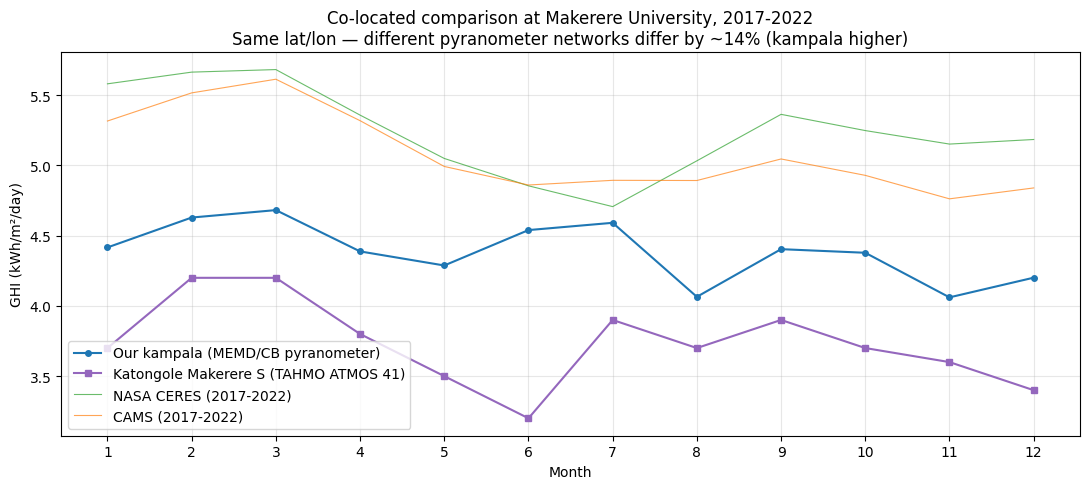

In [15]:
# Pull our kampala monthly climatology over 2017-2022.
kampala_monthly = bq.query(f"""
SELECT EXTRACT(MONTH FROM date) AS month,
       ROUND(AVG(ghi_kwh_m2_day), 4) AS kampala_mean,
       COUNT(*) AS n_days
FROM `{tables.ground_measurements}`
WHERE location = "kampala" AND qc_level = "pass"
  AND date BETWEEN DATE("2017-01-01") AND DATE("2022-12-31")
GROUP BY month ORDER BY month
""")
makerere_row = katongole[katongole["location"] == "Makerere S"]
makerere_long = pd.DataFrame({
    "month": list(range(1, 13)),
    "makerere_mean": [float(makerere_row[m].iloc[0]) for m in month_names],
})
kampala_gh = pygeohash.encode(0.333542, 32.56863, 5)
sat_monthly_2017_22 = bq.query(f"""
SELECT EXTRACT(MONTH FROM date) AS month, source,
       ROUND(AVG(ghi_kwh_m2_day), 4) AS mean_ghi
FROM `{tables.irradiance_daily}`
WHERE geohash5 = "{kampala_gh}"
  AND source IN ("NASA", "CAMS")
  AND date BETWEEN DATE("2017-01-01") AND DATE("2022-12-31")
GROUP BY month, source ORDER BY month, source
""").pivot(index="month", columns="source", values="mean_ghi").reset_index()

calibration_df = (
    kampala_monthly.merge(makerere_long, on="month")
    .merge(sat_monthly_2017_22, on="month")
)
calibration_df["ratio"] = (
    calibration_df["kampala_mean"] / calibration_df["makerere_mean"]
)
annual_ratio = float(calibration_df["ratio"].mean())
print(f"Annual mean ratio (kampala / Makerere S): {annual_ratio:.3f}")
auxscripts.plot_calibration_discrepancy(calibration_df)

## 6.4 — Calibrated Table IV

A single annual ratio (mean of the 12 monthly ratios — ~1.18) rescales
TAHMO Katongole values onto the MEMD/CB scale before scoring. Per-month
ratios would overfit on one co-located pair × 7 years (June's
~1.42 over-corrects Ndejje to 7.8 kWh/m²/day, which is non-physical).
A monotonic linear rescaling shifts RF and satellite RMSEs together —
the *relative* improvement claim is preserved.

In [16]:
comparison_calibrated = comparison.copy()
comparison_calibrated["monthly_obs_calibrated"] = (
    comparison_calibrated["monthly_obs"] * annual_ratio
)
table_iv_calibrated = pd.concat([
    auxscripts.score_table_iv(
        comparison_calibrated,
        label=f"all {comparison_calibrated['location'].nunique()} stations",
        obs_col="monthly_obs_calibrated",
        rf_label="RF (calibrated)",
    ),
    auxscripts.score_table_iv(
        comparison_calibrated[~comparison_calibrated["seen_in_training_geohash5"]],
        label="excluding training-geohash overlaps",
        obs_col="monthly_obs_calibrated",
        rf_label="RF (calibrated)",
    ),
    auxscripts.score_table_iv(
        comparison_calibrated[~comparison_calibrated["seen_in_training_nasa_cell"]],
        label="excluding training-NASA-cell overlaps",
        obs_col="monthly_obs_calibrated",
        rf_label="RF (calibrated)",
    ),
])
print("=== Paper Table IV equivalent — calibration-corrected ===")
print(table_iv_calibrated.to_string(index=False))

=== Paper Table IV equivalent — calibration-corrected ===
                                split           model   n  RMSE  nRMSE_%   MAE  nMAE_%    MBE     R²   IOA
                      all 56 stations RF (calibrated) 672 0.587    11.64 0.415    8.25  0.009  0.312 0.676
                      all 56 stations      NASA CERES 672 0.732    14.53 0.526   10.45  0.346 -0.072 0.608
                      all 56 stations            CAMS 672 0.758    15.05 0.558   11.08  0.462 -0.150 0.637
  excluding training-geohash overlaps RF (calibrated) 600 0.549    10.88 0.389    7.71 -0.027  0.244 0.648
  excluding training-geohash overlaps      NASA CERES 600 0.666    13.21 0.481    9.53  0.308 -0.115 0.609
  excluding training-geohash overlaps            CAMS 600 0.694    13.77 0.520   10.32  0.424 -0.211 0.631
excluding training-NASA-cell overlaps RF (calibrated) 528 0.561    11.03 0.395    7.77 -0.061  0.211 0.633
excluding training-NASA-cell overlaps      NASA CERES 528 0.648    12.74 0.461    9.06

### Residual diagnostics

Three diagnostic views on the §6.4 metrics: covariate-shift KDEs
(training vs Katongole feature distributions), a predicted-vs-observed
scatter, and per-station MBE.

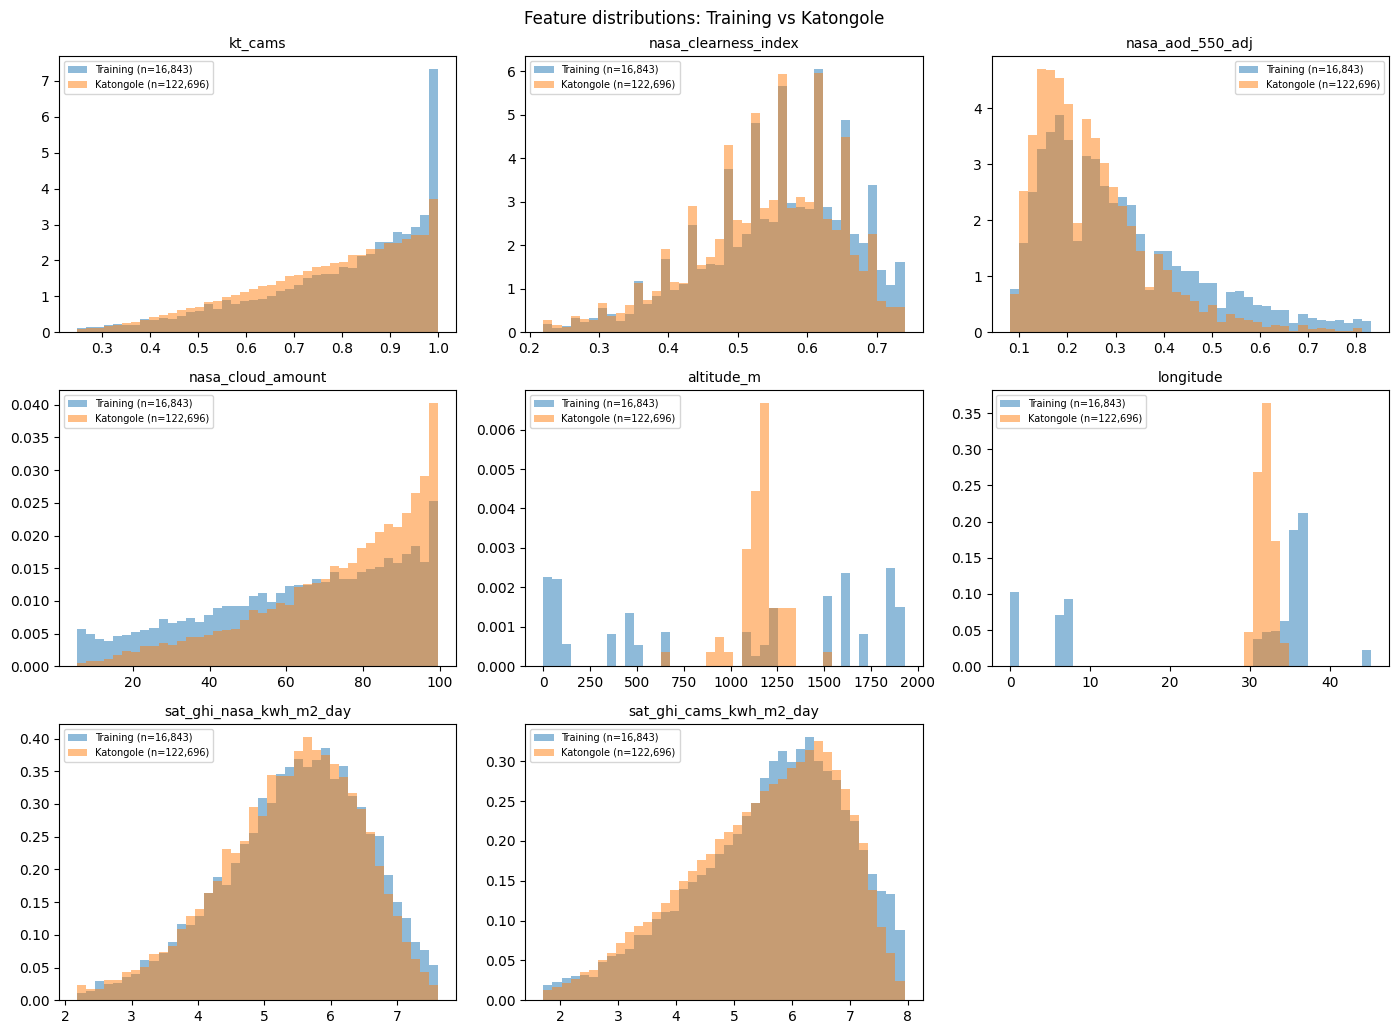

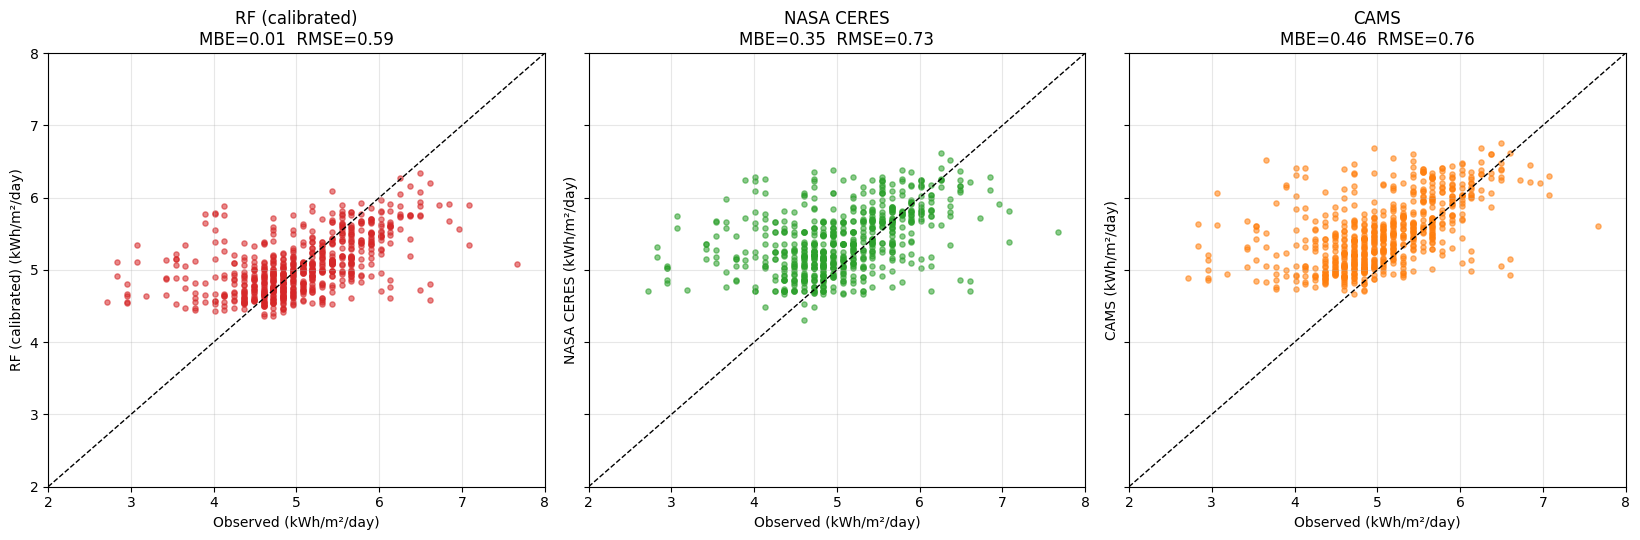

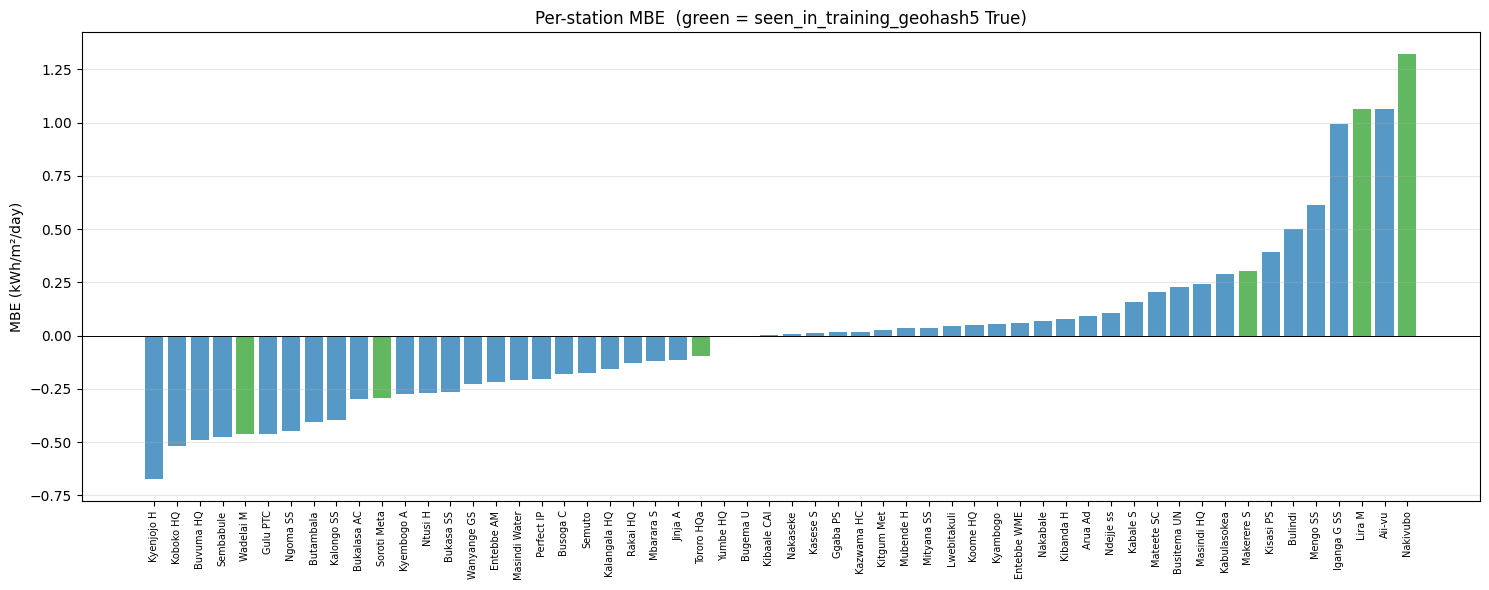

Worst (highest MBE):
               MBE  _highlight
location                      
Mengo SS     0.611       False
Iganga G SS  0.995       False
Lira M       1.062        True
Aii-vu       1.066       False
Nakivubo     1.324        True

Best (lowest MBE):
              MBE  _highlight
location                     
Kyenjojo H -0.676       False
Koboko HQ  -0.517       False
Buvuma HQ  -0.491       False
Sembabule  -0.478       False
Wadelai M  -0.464        True


In [17]:
from susse.evaluation import MeanBiasError
from susse.evaluation.plots import (
    plot_covariate_shift_kde,
    plot_per_station_metric,
    plot_predicted_vs_observed_panels,
)

plot_covariate_shift_kde(
    processed.df, inference_processed.df,
    features=[
        "kt_cams", "nasa_clearness_index", "nasa_aod_550_adj",
        "nasa_cloud_amount", "altitude_m", "longitude",
        "sat_ghi_nasa_kwh_m2_day", "sat_ghi_cams_kwh_m2_day",
    ],
    train_label="Training", val_label="Katongole",
)
plot_predicted_vs_observed_panels(
    comparison_calibrated,
    observed_column="monthly_obs_calibrated",
    predictions={
        "RF (calibrated)": "monthly_pred",
        "NASA CERES":      "sat_ghi_nasa_kwh_m2_day",
        "CAMS":            "sat_ghi_cams_kwh_m2_day",
    },
)
plot_per_station_metric(
    comparison_calibrated,
    observed_column="monthly_obs_calibrated",
    predicted_column="monthly_pred",
    metric=MeanBiasError(),
    highlight_column="seen_in_training_geohash5",
)

## 7 — Figures

* **Figure 2** — 4 × 4 grid of monthly GHI comparison panels for 16
  Katongole stations (mirroring the paper). Five series per panel:
  measured (raw + calibrated), RF predicted, NASA GHI, CAMS GHI.
* **Figure 3** — top RF feature importances.

To pin the figure to a specific 16-station selection (e.g. the paper's
exact list), pass `stations=(...)` to `plot_figure_2_grid`; the default
picks 4 stations per RMSE quartile so the figure spans the model's full
performance range.

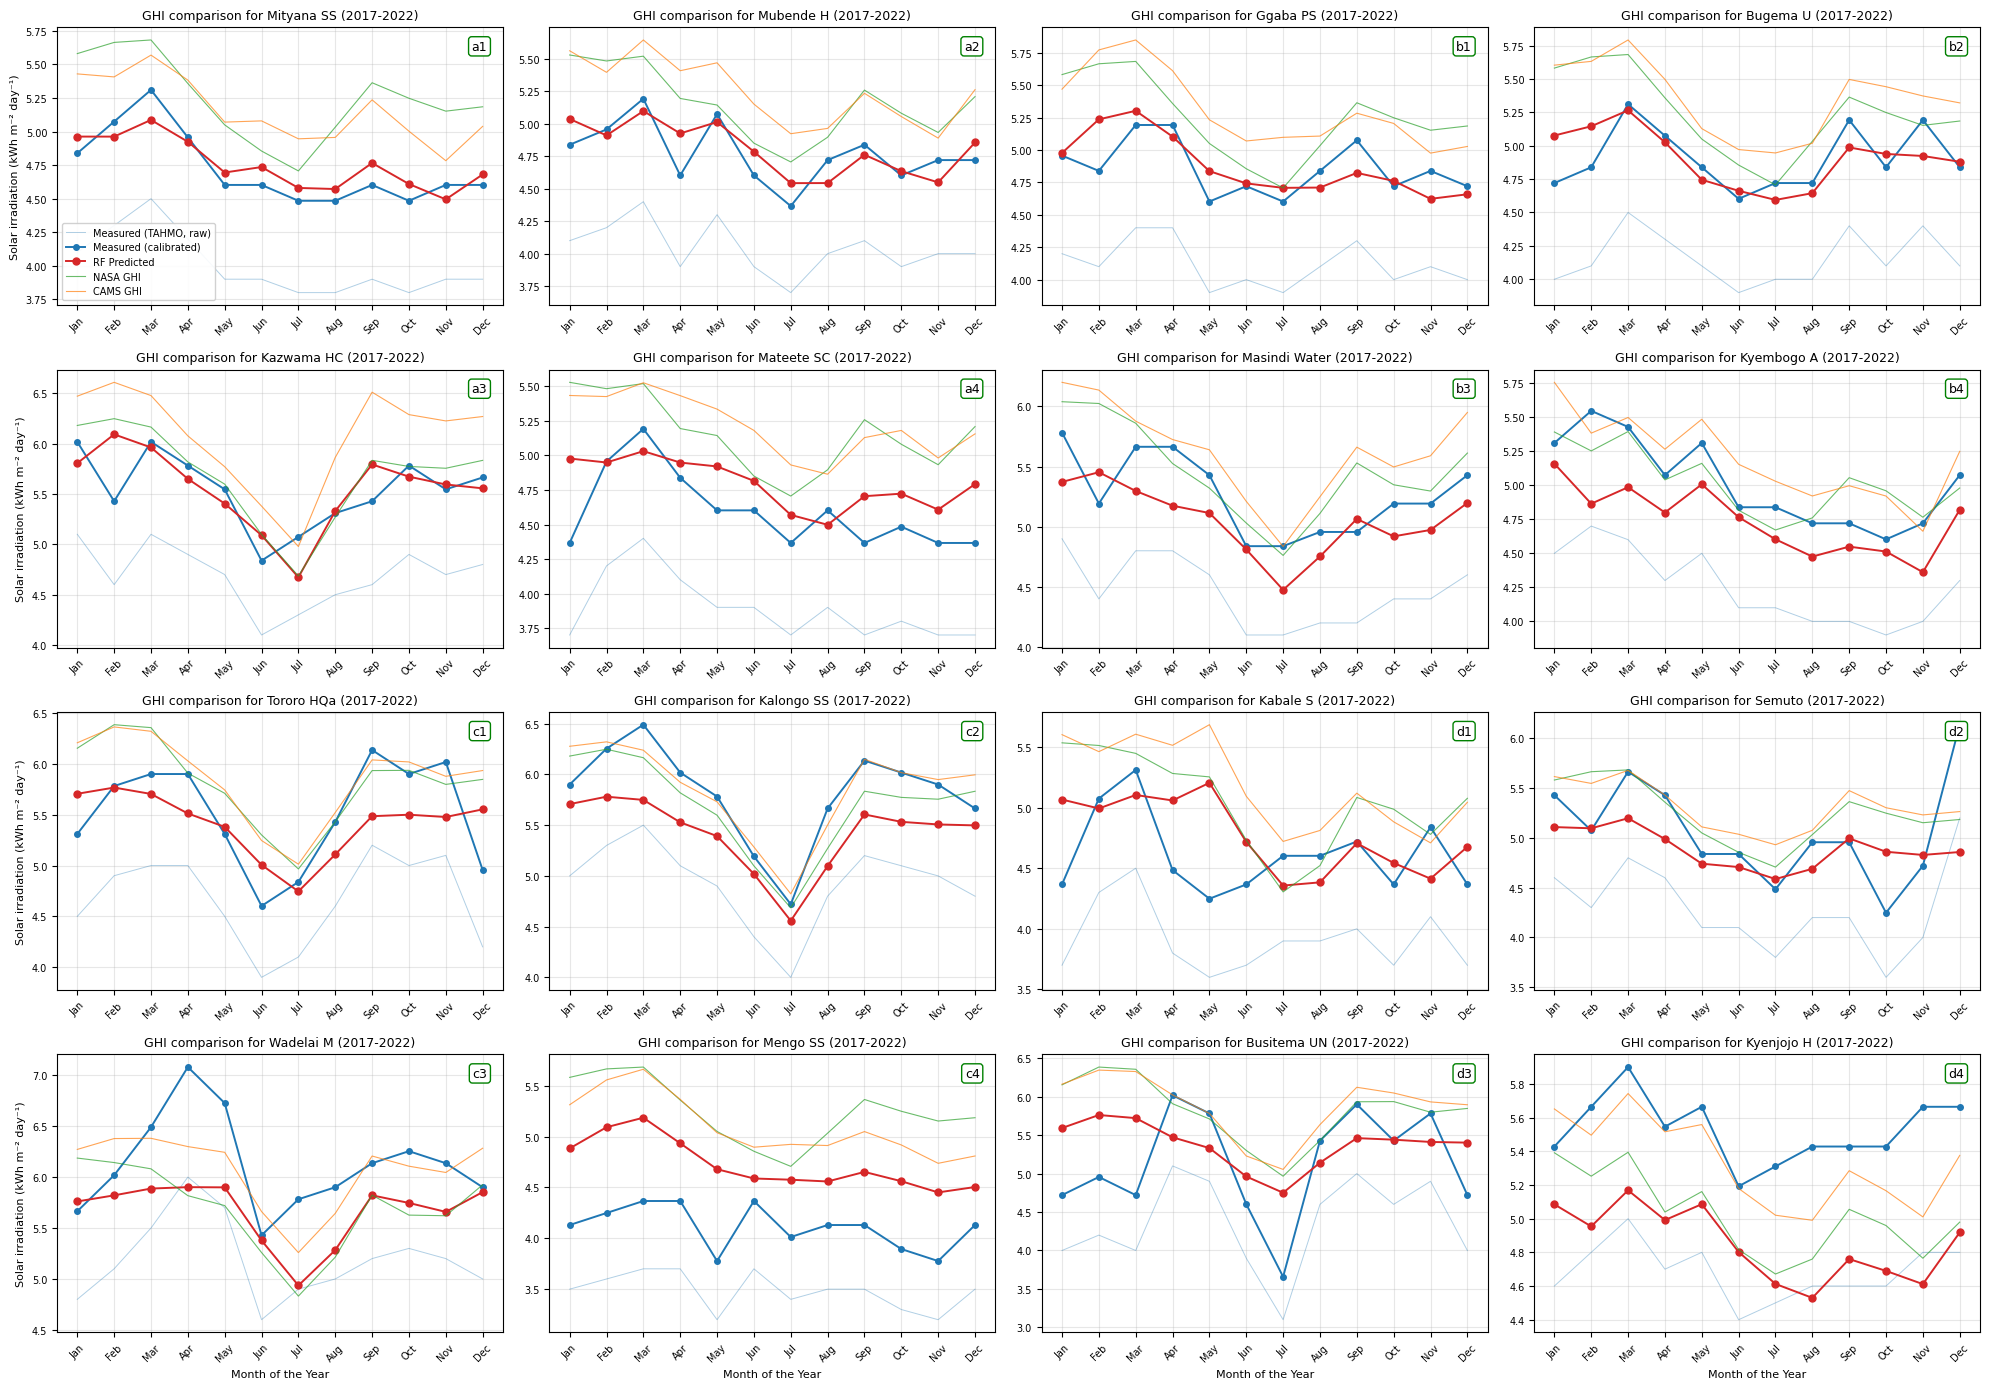

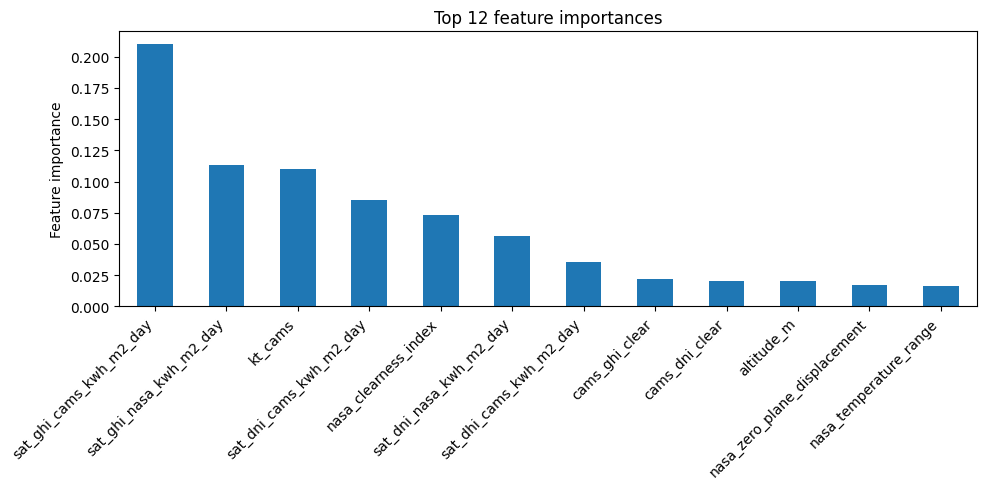

sat_ghi_cams_kwh_m2_day         0.209916
sat_ghi_nasa_kwh_m2_day         0.113409
kt_cams                         0.110029
sat_dni_cams_kwh_m2_day         0.085366
nasa_clearness_index            0.073503
sat_dni_nasa_kwh_m2_day         0.056346
sat_dhi_cams_kwh_m2_day         0.035263
cams_ghi_clear                  0.021671
cams_dni_clear                  0.020066
altitude_m                      0.019974
nasa_zero_plane_displacement    0.016758
nasa_temperature_range          0.016300
dtype: float64

In [18]:
from susse.evaluation.plots import plot_feature_importances_top_n

auxscripts.plot_figure_2_grid(
    comparison_calibrated,
    validation_label=f"{VALIDATION_START_YEAR}-{VALIDATION_END_YEAR}",
)
top_importances = plot_feature_importances_top_n(
    bundle, feature_columns=processed.feature_columns, top_n=12,
)
top_importances

## 8 — Bundle deliverable for Irradiation_Portal

The portal loads a `TrainedBundle` from a fixed directory. After this
notebook runs cleanly the directory at `BUNDLE_DEST` contains:

```
mukiibi_mikelson_2026/
├── model/
│   ├── model_kind.txt       # → "random_forest"
│   ├── params.json          # → {n_estimators: 200, min_samples_leaf: 5, …}
│   └── state.joblib         # the fitted sklearn estimator
├── feature_spec.json        # cleaners + derived features + pass-through cols
├── metadata.json            # train + val + baseline ScoreSet, splitter name, …
└── source_manifest.json     # warehouse-state snapshot used to build the dataset
```

The model predicts absolute GHI directly — `regressor.predict(X)`
returns the bias-corrected value, no inversion step needed.

```python
restored = load_bundle(
    bundle_dir, providers={"altitude": PvlibElevationProvider()},
)
y_pred = restored.regressor.predict(X)  # kWh/m²/day, ready to consume
```

The earlier `load_bundle` call in §6 already verified this round-trip,
so the on-disk bundle is portable to the portal as-is.

## 9 — Deviations from the paper (documented)

| | Paper | This recomputation | Why |
|---|---|---|---|
| **Validation calibration** | none stated | single annual ratio from co-located `kampala` ↔ `Makerere S` (~1.18) | Two ground-sensor networks (MEMD/CB vs TAHMO ATMOS 41) read systematically different at the same site — uncalibrated comparison underestimates the model. Relative-improvement claim preserved under any monotonic rescaling. See §6.3-6.4. |
| Station selection | 24 named stations (paper Table I) | 24 stations by coverage rank | We have 28 available; the heuristic at §2 drops the 4 shortest-coverage. Exact identity of the dropped 4 unlikely to match the paper's. |
| 2-station holdout | named pair (paper Table III) | pair with maximum pairwise haversine | Deterministic and re-runnable. Different from the paper's choice; gives the strongest spatial-generalisation test the data allows. |
| Outlier curation | inline (paper text §II.A) | `cleaners` chain on the `FeatureSpec` | Architectural — the paper's rules now compose like any other cleaner. |
| `day_of_year` integer | included alongside sin/cos | sin/cos only via `CyclicalDayOfYearFeature` | Cyclical encoding is information-equivalent; raw doy adds collinearity. |
| Solar zenith angle | included as a predictor | dropped | NASA POWER doesn't serve daily SZA. |
| `evaporation_land`, `evapotranspiration_energy` | included | dropped | NaN at oceanic stations (ghana_location3 in the Gulf of Guinea); land-only by design. Add `PerStationMeanImputer` if you re-include them. |

## What's next

* If RMSE and IOA differ materially from the paper, inspect the cleaner
  output — the per-(station, year) missing-data threshold and the IQR
  fence are the two most sensitive levers.
* The next iteration should drop `LongitudeFeature` (anti-pattern) and
  replace it with continuous geographical features (terrain ruggedness,
  distance to coast, …).